In [1]:
import pandas as pd
import numpy as np
import os
import ast
from tqdm.notebook import tqdm

from astroquery.esa.euclid import Euclid
from astropy.visualization import make_lupton_rgb
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.io import fits

import matplotlib.pyplot as plt
plt.style.use('dark_background')

In [2]:
#Opening file - useful physical measurements:

path = '/Users/jimenagonzalez/research/SkAI_research/SkAI_SLmodeling/Data/Euclid_morphological_catalog/data/'
filename = 'useful_physical_measurements.parquet'

data = pd.read_parquet(path + filename)
print(len(data))
data2 = data.dropna(subset=["phz_median"])
print('With NaN values for photo-z: ', len(data) - len(data2))
data3 = data2[data2['phz_flags'] == 0]
print('With flags for photo-z: ', len(data2) - len(data3))
data = data3
print('After cuts: ', len(data))
data[['phz_median', 'phz_flags']].head()

399562
With NaN values for photo-z:  8567
With flags for photo-z:  27780
After cuts:  363215


,phz_median,phz_flags
3,0.40,0.0
4,0.18,0.0
7,0.34,0.0
8,0.42,0.0
12,0.79,0.0


In [3]:
# Getting some statistics
print(len(data[data['phz_median'] > 1.1]))
print(np.median(data['phz_median']))

2242
0.3700000047683716


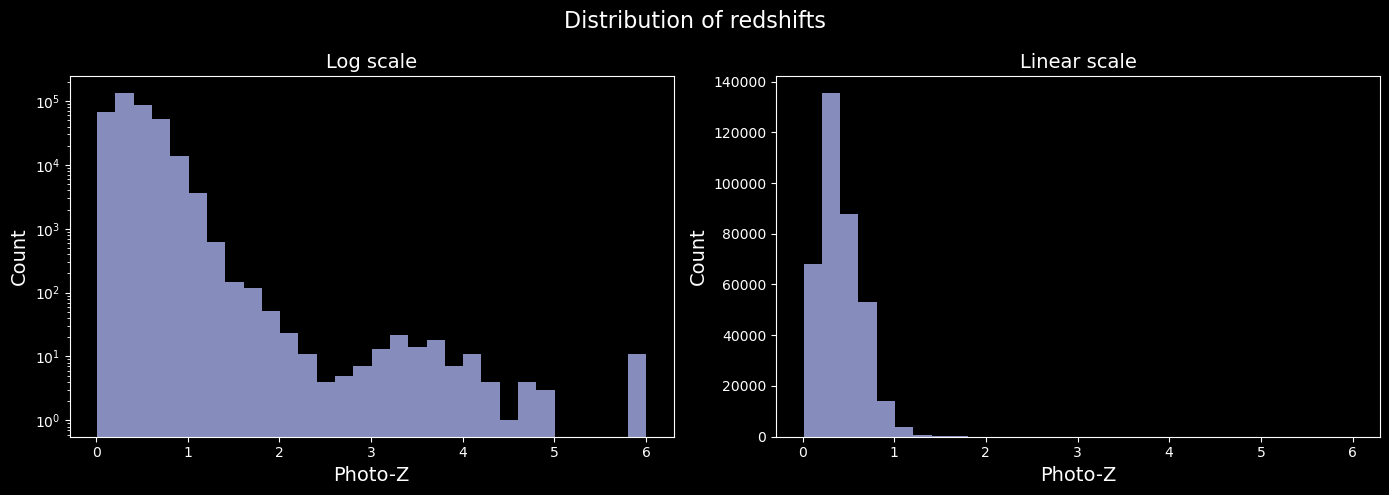

In [4]:
# Photo-z distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=False)

# Left: log scale
axes[0].hist(data["phz_median"], bins=30, color='#a9b0eb', alpha=0.8)
axes[0].set_yscale('log')
axes[0].set_xlabel('Photo-Z', fontsize=14)
axes[0].set_ylabel('Count', fontsize=14)
axes[0].set_title('Log scale', fontsize=14)

# Right: linear scale
axes[1].hist(data["phz_median"], bins=30, color='#a9b0eb', alpha=0.8)
axes[1].set_xlabel('Photo-Z', fontsize=14)
axes[1].set_ylabel('Count', fontsize=14)
axes[1].set_title('Linear scale', fontsize=14)

fig.suptitle('Distribution of redshifts', fontsize=16)
plt.tight_layout()
plt.show()

In [5]:
# Opening file - Morphological catalog
filename = 'morphology_catalogue.parquet'
cat = pd.read_parquet(path + filename)
cat = cat.iloc[0:50]
cat.head()

,object_id,right_ascension,declination,segmentation_area,flux_segmentation,flux_detection_total,flux_vis_1fwhm_aper,mumax_minus_mag,mu_max,ellipticity,...,artifact_saturation_fraction,artifact_other_fraction,artifact_ghost_fraction,log_segmentation_area,log_kron_radius,cutout_width_arcsec,warning_galaxy_fails_training_cuts,jpg_loc_gz_arcsinh_vis_y,jpg_loc_gz_arcsinh_vis_only,jpg_loc_gz_arcsinh_vis_lsb
0,-520564092291261106,52.056409,-29.126111,779,14.553082,15.691106,4.477242,-0.194441,20.716425,0.357027,...,NaN,NaN,NaN,2.891537,1.607289,48.011157,True,/media/home/team_workspaces/Euclid-Consortium/...,/media/home/team_workspaces/Euclid-Consortium/...,/media/home/team_workspaces/Euclid-Consortium/...
1,-520560290287655192,52.056029,-28.765519,863,14.087326,15.247946,4.126712,-0.319044,20.622927,0.039894,...,NaN,NaN,NaN,2.936011,1.555568,41.862106,True,/media/home/team_workspaces/Euclid-Consortium/...,/media/home/team_workspaces/Euclid-Consortium/...,/media/home/team_workspaces/Euclid-Consortium/...
2,-520559452289115027,52.055945,-28.911503,1528,20.475792,23.627728,5.388710,-0.667717,19.798729,0.445131,...,NaN,NaN,NaN,3.184123,1.834273,75.189153,False,/media/home/team_workspaces/Euclid-Consortium/...,/media/home/team_workspaces/Euclid-Consortium/...,/media/home/team_workspaces/Euclid-Consortium/...
3,-520556193290918959,52.055619,-29.091896,1116,15.036468,16.878494,4.510015,-0.902521,19.929144,0.287775,...,NaN,NaN,NaN,3.047664,1.673979,56.397027,True,/media/home/team_workspaces/Euclid-Consortium/...,/media/home/team_workspaces/Euclid-Consortium/...,/media/home/team_workspaces/Euclid-Consortium/...
4,-520555157291800468,52.055516,-29.180047,3699,57.910786,66.777542,6.568681,1.508793,20.847218,0.189365,...,NaN,NaN,NaN,3.568084,1.969616,105.764295,False,/media/home/team_workspaces/Euclid-Consortium/...,/media/home/team_workspaces/Euclid-Consortium/...,/media/home/team_workspaces/Euclid-Consortium/...


# Cutouts using Cutana

In [6]:
# 1. Load the morphology catalogue
cat = pd.read_parquet(path + "morphology_catalogue.parquet")
cat = cat.iloc[0:1000]

# 2. Query all VIS mosaic file paths for the tiles that appear in the catalogue
tile_ids = cat["tile_index"].unique().tolist()
tile_list = ",".join(str(t) for t in tile_ids)

query = f"""
SELECT file_name, file_path, tile_index
FROM q1.mosaic_product
WHERE instrument_name='VIS'
AND tile_index IN ({tile_list})
"""
mosaic = Euclid.launch_job_async(query).get_results().to_pandas()


print(f"Tiles in catalogue: {len(tile_ids)}")
print(f"Mosaic rows returned: {len(mosaic)}")
print(mosaic.head())



# Build full path string per tile
mosaic["full_path"] = mosaic["file_path"] + "/" + mosaic["file_name"]
tile_to_path = dict(zip(mosaic["tile_index"], mosaic["full_path"]))

# 3. Build the Cutana source catalogue
pixel_scale  = 0.1        # arcsec/pixel (Euclid VIS)
cutout_arcsec = 12.0      # desired cutout size
diameter_pix  = int(cutout_arcsec / pixel_scale)  # = 120

cutana_cat = pd.DataFrame({
    "SourceID":       cat["object_id"].astype(str),
    "RA":             cat["right_ascension"],
    "Dec":            cat["declination"],
    "diameter_pixel": diameter_pix,
    "fits_file_paths": cat["tile_index"].map(tile_to_path)
                          .apply(lambda p: str([p]))  # must be list-as-string
})

# Drop galaxies whose tile had no VIS mosaic found
cutana_cat = cutana_cat.dropna(subset=["fits_file_paths"])
cutana_cat.to_csv("cutana_sources.csv", index=False)

print(f"Rows in cutana_cat: {len(cutana_cat)}")
print(cutana_cat.head())
print("\nAny NaN in fits_file_paths?", cutana_cat["fits_file_paths"].isna().sum())

INFO: Query finished. [astroquery.utils.tap.core]
Tiles in catalogue: 1
Mosaic rows returned: 1
                                           file_name  \
0  EUC_MER_BGSUB-MOSAIC-VIS_TILE102042913-EE5E4F_...   

                                           file_path  tile_index  
0  /euclid/repository_idr/iqr1/Q1_R1/MER/10204291...   102042913  
Rows in cutana_cat: 1000
              SourceID         RA        Dec  diameter_pixel  \
0  -520564092291261106  52.056409 -29.126111             120   
1  -520560290287655192  52.056029 -28.765519             120   
2  -520559452289115027  52.055945 -28.911503             120   
3  -520556193290918959  52.055619 -29.091896             120   
4  -520555157291800468  52.055516 -29.180047             120   

                                     fits_file_paths  
0  ['/euclid/repository_idr/iqr1/Q1_R1/MER/102042...  
1  ['/euclid/repository_idr/iqr1/Q1_R1/MER/102042...  
2  ['/euclid/repository_idr/iqr1/Q1_R1/MER/102042...  
3  ['/euclid/repository_idr

In [7]:
from cutana import get_default_config, Orchestrator

config = get_default_config()
config.source_catalogue   = "cutana_sources.csv"
config.output_dir         = "cutouts_vis/"
config.output_format      = "zarr"        # recommended for large datasets
config.target_resolution  = 120           # matches your 12 arcsec cutout
config.selected_extensions = [{"name": "VIS", "ext": "PrimaryHDU"}]
config.channel_weights    = {"VIS": [1.0]}
config.console_log_level  = "INFO"

orchestrator = Orchestrator(config)
results = orchestrator.run()



sample_path = cutana_cat["fits_file_paths"].iloc[0]
print("Raw path string:", sample_path)

# Parse the list-as-string and check the path

parsed = ast.literal_eval(sample_path)
print("Parsed path:", parsed[0])
print("File exists:", os.path.exists(parsed[0]))

print(results) #It fails because I don't have the tile files in my computer

Raw path string: ['/euclid/repository_idr/iqr1/Q1_R1/MER/102042913/VIS/EUC_MER_BGSUB-MOSAIC-VIS_TILE102042913-EE5E4F_20241021T041311.751862Z_00.00.fits']
Parsed path: /euclid/repository_idr/iqr1/Q1_R1/MER/102042913/VIS/EUC_MER_BGSUB-MOSAIC-VIS_TILE102042913-EE5E4F_20241021T041311.751862Z_00.00.fits
File exists: False
{'status': 'failed', 'error': 'Catalogue validation failed: Missing FITS files (1 checked): /euclid/repository_idr/iqr1/Q1_R1/MER/102042913/VIS/EUC_MER_BGSUB-MOSAIC-VIS_TILE102042913-EE5E4F_20241021T041311.751862Z_00.00.fits', 'error_type': 'streaming_init_error'}


# Getting cutouts using the Euclid Archive cutout server

In [8]:
Num_images = 200

filename = 'morphology_catalogue.parquet'
cat = pd.read_parquet(path + filename)
cat = cat.iloc[0:Num_images]
cat.head()

,object_id,right_ascension,declination,segmentation_area,flux_segmentation,flux_detection_total,flux_vis_1fwhm_aper,mumax_minus_mag,mu_max,ellipticity,...,artifact_saturation_fraction,artifact_other_fraction,artifact_ghost_fraction,log_segmentation_area,log_kron_radius,cutout_width_arcsec,warning_galaxy_fails_training_cuts,jpg_loc_gz_arcsinh_vis_y,jpg_loc_gz_arcsinh_vis_only,jpg_loc_gz_arcsinh_vis_lsb
0,-520564092291261106,52.056409,-29.126111,779,14.553082,15.691106,4.477242,-0.194441,20.716425,0.357027,...,NaN,NaN,NaN,2.891537,1.607289,48.011157,True,/media/home/team_workspaces/Euclid-Consortium/...,/media/home/team_workspaces/Euclid-Consortium/...,/media/home/team_workspaces/Euclid-Consortium/...
1,-520560290287655192,52.056029,-28.765519,863,14.087326,15.247946,4.126712,-0.319044,20.622927,0.039894,...,NaN,NaN,NaN,2.936011,1.555568,41.862106,True,/media/home/team_workspaces/Euclid-Consortium/...,/media/home/team_workspaces/Euclid-Consortium/...,/media/home/team_workspaces/Euclid-Consortium/...
2,-520559452289115027,52.055945,-28.911503,1528,20.475792,23.627728,5.388710,-0.667717,19.798729,0.445131,...,NaN,NaN,NaN,3.184123,1.834273,75.189153,False,/media/home/team_workspaces/Euclid-Consortium/...,/media/home/team_workspaces/Euclid-Consortium/...,/media/home/team_workspaces/Euclid-Consortium/...
3,-520556193290918959,52.055619,-29.091896,1116,15.036468,16.878494,4.510015,-0.902521,19.929144,0.287775,...,NaN,NaN,NaN,3.047664,1.673979,56.397027,True,/media/home/team_workspaces/Euclid-Consortium/...,/media/home/team_workspaces/Euclid-Consortium/...,/media/home/team_workspaces/Euclid-Consortium/...
4,-520555157291800468,52.055516,-29.180047,3699,57.910786,66.777542,6.568681,1.508793,20.847218,0.189365,...,NaN,NaN,NaN,3.568084,1.969616,105.764295,False,/media/home/team_workspaces/Euclid-Consortium/...,/media/home/team_workspaces/Euclid-Consortium/...,/media/home/team_workspaces/Euclid-Consortium/...


In [9]:
# Getting all unique tile IDs in the catalog, to produce cutouts in a more efficient way

tile_ids = cat["tile_index"].unique().tolist()
tile_list = ",".join(str(t) for t in tile_ids)

query = f"""SELECT file_name, file_path, tile_index FROM q1.mosaic_product WHERE instrument_name='VIS' AND tile_index IN ({tile_list})"""
mosaic_table = Euclid.launch_job_async(query).get_results()

INFO: Query finished. [astroquery.utils.tap.core]


In [10]:
# Build a lookup dict: tile_index -> (file_path, file_name)
tile_to_mosaic = {row["tile_index"]: (row["file_path"] + "/" + row["file_name"]) for row in mosaic_table}

output_dir = "cutouts_vis/" #Local folder
os.makedirs(output_dir, exist_ok=True)

for _, row in cat.iterrows():
    tile_idx = int(row["tile_index"])
    obj_id   = row["object_id"]
    ra, dec  = row["right_ascension"], row["declination"]

    file_path = tile_to_mosaic.get(tile_idx)
    if file_path is None:
        continue

    coord  = SkyCoord(ra=ra, dec=dec, unit="deg")
    radius = 5 * u.arcsec  # adjust to desired cutout size

    output_file = f"{output_dir}/{obj_id}.fits"

    Euclid.get_cutout(file_path=file_path, instrument="VIS", id=tile_idx, coordinate=coord, radius=radius, output_file=output_file)

#Saving csv file in the same output folder
cat.to_csv(output_dir + 'data.csv', index=False)

ERROR: Cannot retrieve the product for file_path /euclid/repository_idr/iqr1/Q1_R1/MER/102042913/VIS/EUC_MER_BGSUB-MOSAIC-VIS_TILE102042913-EE5E4F_20241021T041311.751862Z_00.00.fits, obsId 102042913, and collection VIS: [Errno 54] Connection reset by peer [astroquery.esa.euclid.core]


# Inspecting image cutouts

Filename: /Users/jimenagonzalez/research/SkAI_research/SkAI_SLmodeling/Data/Euclid_morphological_catalog/cutouts_vis/-520564092291261106.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  None          1 PrimaryHDU      50   (99, 99)   float32   


Image shape: (99, 99)
Image dtype: >f4
Min/Max values: -0.010906984 0.35762697


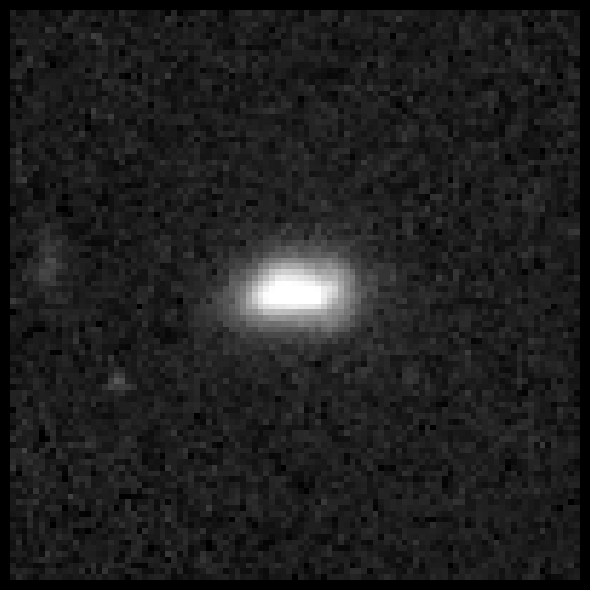

In [11]:
fits_filepath = '/Users/jimenagonzalez/research/SkAI_research/SkAI_SLmodeling/Data/Euclid_morphological_catalog/cutouts_vis/' + '-520564092291261106.fits'

# Open and inspect the file
with fits.open(fits_filepath) as hdul:
    hdul.info()
    image = hdul[0].data
    header = hdul[0].header

print("Image shape:", image.shape)
print("Image dtype:", image.dtype)
print("Min/Max values:", np.nanmin(image), np.nanmax(image))

# Displaying the image
from astropy.visualization import AsinhStretch, PercentileInterval 
# arcsinh stretch between the 0.5th and 99.5th percentile
interval = PercentileInterval(99.5)
vmin, vmax = interval.get_limits(image)
stretch = AsinhStretch()

normalized = stretch((image - vmin) / (vmax - vmin))

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(normalized, origin='lower', cmap='gray')
ax.axis('off')
plt.tight_layout()
plt.show()

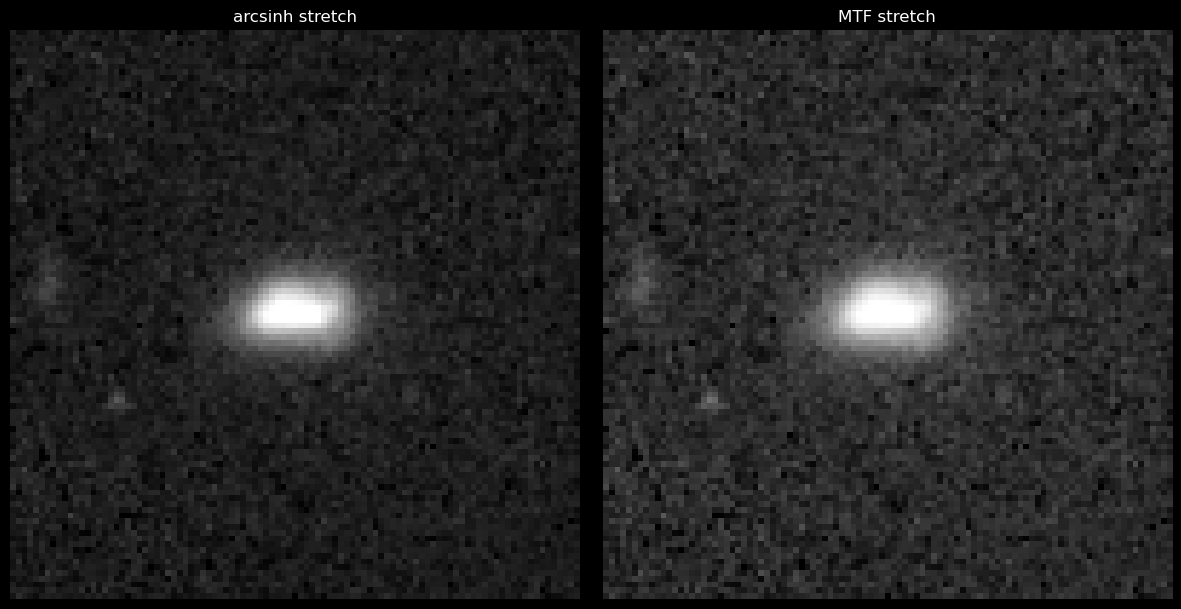

In [12]:
def mtf_stretch(image, midpoint=0.15):
    """
    Midtone Transfer Function stretch, as used in astrophotography
    and some Euclid visualizations. midpoint controls the stretch
    strength: lower = brighter/more contrast in faint regions.
    """
    interval = PercentileInterval(99.5)
    vmin, vmax = interval.get_limits(image)
    x = np.clip((image - vmin) / (vmax - vmin), 0, 1)
    # MTF formula
    stretched = ((midpoint - 1) * x) / ((2 * midpoint - 1) * x - midpoint)
    return np.clip(stretched, 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(normalized, origin='lower', cmap='gray')
axes[0].set_title('arcsinh stretch')
axes[0].axis('off')

axes[1].imshow(mtf_stretch(image, midpoint=0.15), origin='lower', cmap='gray')
axes[1].set_title('MTF stretch')
axes[1].axis('off')

plt.tight_layout()
plt.show()